In [1]:
from dataclasses import dataclass
from pathlib import Path
import itertools
import math
import os
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

cwd = Path.cwd().resolve()
repo_root = next(
    p for p in (cwd, *cwd.parents)
    if (p / "rebound").is_dir() and (p / "src").is_dir()
)
sys.path.insert(0, str(repo_root))
import rebound

QUICK = os.environ.get("REBOUND_BENCHMARK_QUICK", "0") == "1"
TOP_PERIODS = 0.05 if QUICK else 100.0
N_OUTPUT = 24 if QUICK else 600
TIMING_REPEATS = 1 if QUICK else 3
SCREEN_DIVISORS = (20,) if QUICK else (10, 20, 40, 80)
MAIN_DIVISOR = 20
ENERGY_FLOOR = 5e-16

print("rebound Python:", rebound.__file__)
print("rebound library:", rebound.__libpath__)
print("mode:", "QUICK validation" if QUICK else "FULL benchmark")
print(f"top-level periods={TOP_PERIODS}, outputs={N_OUTPUT}, timing repeats={TIMING_REPEATS}")

rebound Python: /Users/ziruiliu/Ray/school/2026_summer/Hanno/rebound/rebound/__init__.py
rebound library: /Users/ziruiliu/Ray/school/2026_summer/Hanno/rebound/librebound.so
mode: FULL benchmark
top-level periods=100.0, outputs=600, timing repeats=3


In [2]:
@dataclass(frozen=True)
class Leaf:
    name: str
    mass: float


@dataclass(frozen=True)
class OrbitNode:
    name: str
    left: object
    right: object
    a: float
    e: float = 0.0
    inc_deg: float = 0.0
    Omega_deg: float = 0.0
    omega_deg: float = 0.0
    f_deg: float = 0.0


@dataclass(frozen=True)
class Case:
    key: str
    title: str
    category: str
    description: str
    root: object
    expected: str
    source_label: str
    source_url: str
    hj_mode: str = "fixed"


def L(name, mass):
    return Leaf(name, float(mass))


def O(name, left, right, a, e=0.0, inc=0.0, Omega=0.0, omega=0.0, f=0.0):
    return OrbitNode(name, left, right, float(a), float(e), float(inc),
                     float(Omega), float(omega), float(f))


def _shift_particles(particles, target_com):
    shifted = []
    for name, particle in particles:
        p = particle.copy()
        for attr in ("x", "y", "z", "vx", "vy", "vz"):
            setattr(p, attr, getattr(p, attr) + getattr(target_com, attr))
        shifted.append((name, p))
    return shifted


def build_hierarchy(node):
    """Return barycentric leaf particles, mass, name tree, periods, and node metadata."""
    if isinstance(node, Leaf):
        return [(node.name, rebound.Particle(m=node.mass))], node.mass, node.name, [], []

    left_particles, left_mass, left_tree, left_periods, left_meta = build_hierarchy(node.left)
    right_particles, right_mass, right_tree, right_periods, right_meta = build_hierarchy(node.right)

    pair = rebound.Simulation()
    pair.G = 1.0
    pair.add(m=left_mass)
    pair.add(
        m=right_mass, a=node.a, e=node.e,
        inc=np.deg2rad(node.inc_deg), Omega=np.deg2rad(node.Omega_deg),
        omega=np.deg2rad(node.omega_deg), f=np.deg2rad(node.f_deg),
    )
    pair.move_to_com()
    period = 2*np.pi*np.sqrt(node.a**3/(left_mass + right_mass))
    particles = (
        _shift_particles(left_particles, pair.particles[0])
        + _shift_particles(right_particles, pair.particles[1])
    )
    metadata = left_meta + right_meta + [{
        "name": node.name, "a": node.a, "e": node.e,
        "inc_deg": node.inc_deg, "period": period,
    }]
    return (
        particles, left_mass + right_mass, [left_tree, right_tree],
        left_periods + right_periods + [period], metadata,
    )


def leaf_names(node):
    if isinstance(node, Leaf):
        return [node.name]
    return leaf_names(node.left) + leaf_names(node.right)


def hierarchy_orders(node):
    """All depth-first leaf orders obtained by swapping children at every node."""
    if isinstance(node, Leaf):
        return [(node.name,)]
    left = hierarchy_orders(node.left)
    right = hierarchy_orders(node.right)
    orders = [a+b for a in left for b in right] + [b+a for a in left for b in right]
    return list(dict.fromkeys(orders))


def tree_to_indices(tree, order):
    index = {name: i+1 for i, name in enumerate(order)}
    def convert(item):
        return index[item] if isinstance(item, str) else [convert(item[0]), convert(item[1])]
    return convert(tree)


def case_data(case):
    particles, total_mass, name_tree, periods, metadata = build_hierarchy(case.root)
    return {
        "particles": dict(particles), "natural_order": tuple(name for name, _ in particles),
        "total_mass": total_mass, "name_tree": name_tree,
        "periods": np.asarray(periods), "p_min": min(periods), "p_top": periods[-1],
        "metadata": metadata,
    }


def make_simulation(case, order, integrator, divisor=MAIN_DIVISOR):
    data = case_data(case)
    sim = rebound.Simulation()
    sim.G = 1.0
    for name in order:
        sim.add(data["particles"][name])
    sim.move_to_com()
    sim.integrator = integrator
    sim.dt = data["p_min"]/divisor
    if integrator == "ias15":
        sim.integrator.epsilon = 1e-12
    return sim, data, tree_to_indices(data["name_tree"], order)


def relative_energy_error(sim, energy0):
    return max(abs((sim.energy()-energy0)/energy0), ENERGY_FLOOR)


def named_state(sim, order):
    return {
        name: np.array([p.x, p.y, p.z, p.vx, p.vy, p.vz], dtype=float)
        for name, p in zip(order, sim.particles)
    }


def normalized_state_errors(state, reference):
    """Return separate dimensionless RMS position and velocity errors."""
    names = sorted(reference)
    a = np.asarray([state[name] for name in names])
    b = np.asarray([reference[name] for name in names])
    position_error = np.sqrt(np.mean((a[:, :3]-b[:, :3])**2))
    velocity_error = np.sqrt(np.mean((a[:, 3:]-b[:, 3:])**2))
    position_scale = max(np.sqrt(np.mean(b[:, :3]**2)), np.finfo(float).eps)
    velocity_scale = max(np.sqrt(np.mean(b[:, 3:]**2)), np.finfo(float).eps)
    return {"position": position_error/position_scale,
            "velocity": velocity_error/velocity_scale}

In [3]:
CASES = [
    Case(
        "01_hd98800", "Misaligned 2+2 stellar quadruple", "branching stellar quadruple",
        "HD 98800-inspired: two eccentric tight binaries orbit each other on a wider, strongly inclined orbit.",
        O("outer", O("A binary", L("A1",1.1), L("A2",.9),1,.1),
          O("B binary", L("B1",.9), L("B2",.6),1.3,.2,35),18,.15,60),
        "win", "HD 98800 orbital architecture", "https://arxiv.org/abs/2109.02841"),
    Case(
        "02_ph1", "Circumbinary planet in a 2+2 quadruple", "planetary 3+2 branch",
        "PH1/Kepler-64-inspired: a circumbinary planet belongs to one stellar pair while another tight binary forms the other branch.",
        O("outer", O("planetary A", O("A binary",L("A1",1.4),L("A2",.4),1,.2),L("P",.001),4,.03,3),
          O("B binary",L("B1",.8),L("B2",.6),1.2,.1,20),18,.1,15),
        "win", "PH1 discovery", "https://arxiv.org/abs/1210.3612"),
    Case(
        "03_30ari", "S-type planet in a 2+2 quadruple", "planet inside one stellar branch",
        "30 Ari-inspired and mass-amplified: a close S-type companion is nested around one member of a stellar binary, opposite a second stellar binary.",
        O("outer", O("B system",O("host+planet",L("B host",1.2),L("P",.1),.1,.02),L("B companion",.5),.7,.2,8),
          O("A binary",L("A1",.9),L("A2",.7),.2,.1,25),5,.1,20),
        "win", "30 Ari in nested multiple dynamics", "https://academic.oup.com/mnras/article/459/3/2827/2595187"),
    Case(
        "04_castor", "Three-binary sextuple", "three-level stellar sextuple",
        "Castor-inspired and rescaled: two binaries form an inner 2+2 quadruple and a third binary orbits that quadruple.",
        O("outer", O("AB quadruple",O("A binary",L("A1",1.5),L("A2",.5),.5,.05),
          O("B binary",L("B1",1.3),L("B2",.4),.7,.1,15),5,.15,30),
          O("C binary",L("C1",.6),L("C2",.6),.4,.02,50),18,.1,40),
        "win", "Castor sextuple architecture", "https://www.aspbooks.org/a/volumes/article_details/?paper_id=37069"),
    Case(
        "05_double_multiplanet", "Two S-type multiplanet systems", "two planetary branches",
        "A mass-amplified compact analogue of a wide stellar binary whose two components each host a two-planet system.",
        O("stellar orbit",O("A system",O("A inner",L("A",1),L("A p1",.1),.4,.02),L("A p2",.05),1.8,.04,3),
          O("B system",O("B inner",L("B",.8),L("B p1",.08),.45,.03,5),L("B p2",.04),2,.05,8),10,.15,20),
        "win", "Planets in binary-star systems", "https://www.aanda.org/articles/aa/full_html/2026/03/aa57244-25/aa57244-25.html"),
    Case(
        "06_double_moons", "Two planet–moon systems in a stellar binary", "nested satellite branches",
        "Each star hosts a giant planet–moon pair; both moon-scale Kepler problems live below the wide stellar orbit.",
        O("stellar orbit",O("A system",L("A",1),O("A planet-moon",L("A planet",.2),L("A moon",.08),.02,.02,5),.3,.03),
          O("B system",L("B",.8),O("B planet-moon",L("B planet",.16),L("B moon",.064),.02,.03,8),.32,.04,10),1.8,.1,25),
        "win", "Nested-binary hierarchy formalism", "https://arxiv.org/abs/1511.00944"),
    Case(
        "07_triple_planets", "Planet-hosting hierarchical triple", "two occupied triple branches",
        "A mass-amplified compact analogue: an inner binary carries a circumbinary planet while the tertiary carries an S-type planet.",
        O("outer",O("AB+planet",O("AB",L("A",1),L("B",.7),.6,.1),L("AB planet",.05),2,.04,5),
          O("C+planet",L("C",.8),L("C planet",.1),.3,.02,12),8,.1,20),
        "win", "Planetary zones in hierarchical triples", "https://academic.oup.com/mnras/article/382/4/1432/1142027"),
    Case(
        "08_twin_circumbinary", "Twin circumbinary planetary systems", "two planetary triple branches",
        "Two tight stellar binaries each carry a circumbinary planet; the planetary triples orbit one another.",
        O("outer",O("A triple",O("A binary",L("A1",1),L("A2",.6),.8,.1),L("A planet",.001),3.5,.03,4),
          O("B triple",O("B binary",L("B1",.9),L("B2",.5),1,.08,15),L("B planet",.001),4,.04,18),15,.1,25),
        "win", "Arbitrary multiplanet and multistar hierarchies", "https://arxiv.org/abs/1511.00944"),
    Case(
        "09_exomoon_quadruple", "Circumbinary planet–moon plus outer binary", "binary planet branch in a quadruple",
        "A planet–moon binary orbits one stellar binary while a second stellar binary forms the other outer branch.",
        O("outer",O("left",O("A binary",L("A1",1),L("A2",.7),.4,.1),
          O("planet-moon",L("planet",.2),L("moon",.1),.4,.02,5),2.5,.04,8),
          O("B binary",L("B1",.8),L("B2",.6),.4,.1,25),12,.1,20),
        "win", "Nested-binary hierarchy formalism", "https://arxiv.org/abs/1511.00944"),
    Case(
        "10_binary_forest", "Balanced eight-body binary forest", "deep balanced hierarchy",
        "Four tight binaries form two 2+2 quadruples, which then orbit one another; this tests tree depth and traversal cost.",
        O("outer",O("Q1",O("b1",L("a1",1),L("a2",.8),.6,.05),O("b2",L("b1a",.9),L("b2a",.7),.7,.08,10),4,.1,25),
          O("Q2",O("b3",L("c1",.8),L("c2",.6),.8,.06,20),O("b4",L("d1",.7),L("d2",.5),.9,.1,30),4.5,.12,35),42,.1,40),
        "win", "Architecture of hierarchical stellar systems", "https://www.mdpi.com/2218-1997/7/9/352"),
    Case(
        "11_triple_control", "Ordered hierarchical triple", "comb control",
        "The natural tree [[A,B],C] is already ordinary Jacobi form, so fixed-tree HJ should not improve accuracy.",
        O("outer",O("inner",L("A",1),L("B",.7),1,.1),L("C",.4),15,.15,20),
        "control", "Hierarchical triple systems", "https://academic.oup.com/mnras/article/382/4/1432/1142027"),
    Case(
        "12_3plus1_control", "3+1 stellar quadruple", "automatic-tree comb control",
        "A pure comb [[[A,B],C],D] is representable by WHFast ordering; automatic HJ rebuilding adds overhead without changing the split.",
        O("outer",O("triple",O("inner",L("A",1),L("B",.7),1,.1),L("C",.5),6,.1,10),L("D",.3),25,.1,20),
        "control", "3+1 hierarchical multiples", "https://arxiv.org/abs/1511.00944", hj_mode="automatic"),
    Case(
        "13_pluto_control", "Scaled Sun–Pluto–Charon–moon chain", "satellite comb control",
        "A mass-amplified Pluto analogue: Pluto–Charon plus two small circumbinary moons orbit a Sun. Reordering puts the whole hierarchy in one ordinary Jacobi comb.",
        O("heliocentric",L("Sun",1),O("Hydra orbit",O("Nix orbit",O("Pluto-Charon",L("Pluto",1e-3),L("Charon",1.2e-4),.05,.02),
          L("Nix",1e-8),.12,.01),L("Hydra",1e-8),.2,.01),1.2,.2,17),
        "control", "NASA Pluto moon system", "https://science.nasa.gov/dwarf-planets/pluto/moons/facts/"),
]

assert len(CASES) == 13
assert sum(case.expected == "win" for case in CASES) == 10
print("cases:", len(CASES), "expected wins:", sum(c.expected == "win" for c in CASES))

cases: 13 expected wins: 10


In [4]:
for number, case in enumerate(CASES, 1):
    data = case_data(case)
    display(Markdown(
        f"### {number}. {case.title}\n\n"
        f"**Category:** {case.category}.  **Expected result:** {case.expected}.  "
        f"**HJ mode:** {case.hj_mode}.\n\n{case.description}\n\n"
        f"Source: [{case.source_label}]({case.source_url})"
    ))
    print("name tree:", data["name_tree"])
    print(f"N={len(data['natural_order'])}, P_top/P_min={data['p_top']/data['p_min']:.2f}")

### 1. Misaligned 2+2 stellar quadruple

**Category:** branching stellar quadruple.  **Expected result:** win.  **HJ mode:** fixed.

HD 98800-inspired: two eccentric tight binaries orbit each other on a wider, strongly inclined orbit.

Source: [HD 98800 orbital architecture](https://arxiv.org/abs/2109.02841)

name tree: [['A1', 'A2'], ['B1', 'B2']]
N=4, P_top/P_min=57.73


### 2. Circumbinary planet in a 2+2 quadruple

**Category:** planetary 3+2 branch.  **Expected result:** win.  **HJ mode:** fixed.

PH1/Kepler-64-inspired: a circumbinary planet belongs to one stellar pair while another tight binary forms the other branch.

Source: [PH1 discovery](https://arxiv.org/abs/1210.3612)

name tree: [[['A1', 'A2'], 'P'], ['B1', 'B2']]
N=5, P_top/P_min=57.27


### 3. S-type planet in a 2+2 quadruple

**Category:** planet inside one stellar branch.  **Expected result:** win.  **HJ mode:** fixed.

30 Ari-inspired and mass-amplified: a close S-type companion is nested around one member of a stellar binary, opposite a second stellar binary.

Source: [30 Ari in nested multiple dynamics](https://academic.oup.com/mnras/article/459/3/2827/2595187)

...

name tree: [['A', 'B'], 'C']
N=3, P_top/P_min=52.27


### 12. 3+1 stellar quadruple

**Category:** automatic-tree comb control.  **Expected result:** control.  **HJ mode:** automatic.

A pure comb [[[A,B],C],D] is representable by WHFast ordering; automatic HJ rebuilding adds overhead without changing the split.

Source: [3+1 hierarchical multiples](https://arxiv.org/abs/1511.00944)

name tree: [[['A', 'B'], 'C'], 'D']
N=4, P_top/P_min=103.08


### 13. Scaled Sun–Pluto–Charon–moon chain

**Category:** satellite comb control.  **Expected result:** control.  **HJ mode:** fixed.

A mass-amplified Pluto analogue: Pluto–Charon plus two small circumbinary moons orbit a Sun. Reordering puts the whole hierarchy in one ordinary Jacobi comb.

Source: [NASA Pluto moon system](https://science.nasa.gov/dwarf-planets/pluto/moons/facts/)

name tree: ['Sun', [[['Pluto', 'Charon'], 'Nix'], 'Hydra']]
N=5, P_top/P_min=3.93


## Give ordinary WHFast a physically meaningful ordering

Jacobi coordinates depend on particle order. For each branching case, the next cell tests every depth-first order obtained by swapping children of the physical hierarchy and selects the order with the smallest short-pilot maximum energy error. This prevents an artificial HJ victory caused only by a poor input order. For each comb control, the exact hierarchy-compatible Jacobi order is imposed rather than selected by a short pilot, which can favor a transiently good but physically mismatched order.

In [5]:
def short_error_run(case, order, integrator, divisor=20, horizon=None, samples=20):
    sim, data, tree = make_simulation(case, order, integrator, divisor)
    if horizon is None:
        horizon = min(0.05*data["p_top"], 50*data["p_min"])
    total_steps = max(1, int(np.ceil(horizon/sim.dt)))
    marks = np.unique(np.linspace(1, total_steps, samples, dtype=int))
    energy0 = sim.energy()
    if integrator == "whfast_hj" and case.hj_mode == "fixed":
        sim.integrate(sim.t, given_tree=True, tree=tree)
    previous = 0
    errors = []
    start = time.perf_counter()
    with warnings.catch_warnings():
        warnings.simplefilter("error")
        for mark in marks:
            sim.steps(int(mark-previous))
            previous = int(mark)
            error = relative_energy_error(sim, energy0)
            if not np.isfinite(error):
                raise FloatingPointError(f"non-finite energy in {case.key}/{integrator}")
            errors.append(error)
    return max(errors), time.perf_counter()-start


def optimize_whfast_order(case):
    candidates = hierarchy_orders(case.root)
    scored = []
    for order in candidates:
        error, elapsed = short_error_run(case, order, "whfast")
        scored.append((error, elapsed, order))
    scored.sort(key=lambda row: row[0])
    return scored[0][2], scored


EXACT_COMB_ORDERS = {
    "11_triple_control": ("A", "B", "C"),
    "12_3plus1_control": ("A", "B", "C", "D"),
    "13_pluto_control": ("Pluto", "Charon", "Nix", "Hydra", "Sun"),
}


OPTIMAL_ORDERS = {}
ordering_start = time.perf_counter()
for case in CASES:
    if case.key in EXACT_COMB_ORDERS:
        best_order = EXACT_COMB_ORDERS[case.key]
        pilot_error, pilot_seconds = short_error_run(case, best_order, "whfast")
        scores = [(pilot_error, pilot_seconds, best_order)]
        selection = "exact comb"
    else:
        best_order, scores = optimize_whfast_order(case)
        selection = f"best of {len(scores)}"
    OPTIMAL_ORDERS[case.key] = best_order
    print(f"{case.key:24s} {selection:12s} order={best_order} "
          f"pilot_error={scores[0][0]:.3e}")
print(f"ordering pilots completed in {time.perf_counter()-ordering_start:.2f} s")

01_hd98800               best of 8    order=('A1', 'A2', 'B1', 'B2') pilot_error=8.895e-04
02_ph1                   best of 16   order=('P', 'A2', 'A1', 'B1', 'B2') pilot_error=6.083e-04
03_30ari                 best of 16   order=('A2', 'A1', 'B companion', 'P', 'B host') pilot_error=2.137e-04
04_castor                best of 32   order=('A1', 'A2', 'B1', 'B2', 'C1', 'C2') pilot_error=3.936e-04
05_double_multiplanet    best of 32   order=('A p1', 'A', 'A p2', 'B p2', 'B', 'B p1') pilot_error=1.570e-04
06_double_moons          best of 32   order=('A planet', 'A moon', 'A', 'B', 'B planet', 'B moon') pilot_error=1.863e-04
07_triple_planets        best of 16   order=('B', 'A', 'AB planet', 'C', 'C planet') pilot_error=1.718e-04
08_twin_circumbinary     best of 32   order=('A planet', 'A2', 'A1', 'B planet', 'B1', 'B2') pilot_error=4.368e-04
09_exomoon_quadruple     best of 32   order=('A2', 'A1', 'planet', 'moon', 'B1', 'B2') pilot_error=1.441e-03
10_binary_forest         best of 128  or

## Timestep pre-screen

The full run checks $\Delta t=P_{\min}/d$ for $d\in\{10,20,40,80\}$ over a short horizon. A same-step candidate passes the primary HJ criterion when

$$
\frac{\max |\Delta E/E_0|_{\rm WHFast}}
{\max |\Delta E/E_0|_{\rm HJ}}\ge 10
$$

and the short HJ runtime is no more than three times the WHFast runtime. Quick mode checks only $d=20$. The final classification is recomputed from the long trajectory and independent timing runs.

In [6]:
SCREEN = []
for case in CASES[:10]:
    data = case_data(case)
    horizon = min(0.10*data["p_top"], 200*data["p_min"])
    for divisor in SCREEN_DIVISORS:
        order = OPTIMAL_ORDERS[case.key]
        err_w, sec_w = short_error_run(case, order, "whfast", divisor, horizon, 32)
        err_h, sec_h = short_error_run(case, order, "whfast_hj", divisor, horizon, 32)
        ratio = err_w/err_h
        passed = ratio >= 10 and sec_h/sec_w <= 3
        SCREEN.append({"case":case.key, "divisor":divisor, "whfast":err_w,
                       "hj":err_h, "error_ratio":ratio, "runtime_ratio":sec_h/sec_w,
                       "passed":passed})
        print(f"{case.key:24s} P/{divisor:<2d} error ratio={ratio:9.2f} "
              f"runtime ratio={sec_h/sec_w:5.2f} {'PASS' if passed else 'review'}")

01_hd98800               P/10 error ratio=    86.05 runtime ratio= 0.29 PASS
01_hd98800               P/20 error ratio=    90.39 runtime ratio= 0.57 PASS
01_hd98800               P/40 error ratio=    91.29 runtime ratio= 1.37 PASS
01_hd98800               P/80 error ratio=    90.77 runtime ratio= 1.64 PASS
02_ph1                   P/10 error ratio=    64.16 runtime ratio= 0.35 PASS
02_ph1                   P/20 error ratio=    60.16 runtime ratio= 0.82 PASS
02_ph1                   P/40 error ratio=    59.15 runtime ratio= 1.35 PASS
02_ph1                   P/80 error ratio=    57.50 runtime ratio= 1.60 PASS
03_30ari                 P/10 error ratio=    18.32 runtime ratio= 1.12 PASS
03_30ari                 P/20 error ratio=    12.64 runtime ratio= 1.34 PASS
03_30ari                 P/40 error ratio=     8.41 runtime ratio= 1.44 review
03_30ari                 P/80 error ratio=     6.36 runtime ratio= 1.26 review
04_castor                P/10 error ratio=    24.16 runtime ratio= 0.63 

## Long energy histories and independent timing

The main symplectic runs use $\Delta t=P_{\min}/20$. Fixed HJ trees are installed once before stepping, so parsing is excluded from integration time. The automatic-tree control rebuilds its hierarchy inside every HJ step. For each integrator, the sampled full trajectory is the unmeasured warm-up; runtime measurements then use three fresh one-shot simulations and do not include setup, plotting, or energy sampling.

In [7]:
def trajectory(case, integrator, order):
    sim, data, tree = make_simulation(case, order, integrator)
    sampling_dt = sim.dt
    total_steps = max(1, int(np.ceil(TOP_PERIODS*data["p_top"]/sampling_dt)))
    marks = np.unique(np.linspace(1, total_steps, N_OUTPUT, dtype=int))
    energy0 = sim.energy()
    com0 = sim.com()
    if integrator == "whfast_hj" and case.hj_mode == "fixed":
        sim.integrate(sim.t, given_tree=True, tree=tree)
    times, errors = [], []
    previous = 0
    start = time.perf_counter()
    with warnings.catch_warnings():
        warnings.simplefilter("error")
        for mark in marks:
            target = mark*sampling_dt
            if integrator == "ias15":
                sim.integrate(target, exact_finish_time=1)
            else:
                sim.steps(int(mark-previous))
            previous = int(mark)
            times.append(sim.t/data["p_top"])
            errors.append(relative_energy_error(sim, energy0))
    values = np.asarray(errors)
    if not np.all(np.isfinite(values)):
        raise FloatingPointError(f"non-finite trajectory in {case.key}/{integrator}")
    com = sim.com()
    position_drift = float(np.linalg.norm(
        [com.x-com0.x, com.y-com0.y, com.z-com0.z]))
    velocity_drift = float(np.linalg.norm(
        [com.vx-com0.vx, com.vy-com0.vy, com.vz-com0.vz]))
    length_scale = max(item["a"] for item in data["metadata"])
    velocity_scale = 2*np.pi*length_scale/data["p_top"]
    relative_com_drift = max(position_drift/length_scale,
                             velocity_drift/velocity_scale)
    if not np.isfinite(relative_com_drift) or relative_com_drift > 1e-8:
        raise AssertionError(
            f"center-of-mass drift in {case.key}/{integrator}: "
            f"dx/a={position_drift/length_scale:.3e}, "
            f"dv/v={velocity_drift/velocity_scale:.3e}")
    return {"time":np.asarray(times), "energy_error":values,
            "max_error":float(values.max()), "rms_error":float(np.sqrt(np.mean(values**2))),
            "state":named_state(sim, order), "trajectory_seconds":time.perf_counter()-start,
            "steps":total_steps, "com_position_drift":position_drift,
            "com_velocity_drift":velocity_drift,
            "relative_com_drift":relative_com_drift}


def timed_integration(case, integrator, order):
    durations = []
    for repeat in range(TIMING_REPEATS):
        sim, data, tree = make_simulation(case, order, integrator)
        total_steps = max(1, int(np.ceil(TOP_PERIODS*data["p_top"]/sim.dt)))
        target = total_steps*sim.dt
        if integrator == "whfast_hj" and case.hj_mode == "fixed":
            sim.integrate(sim.t, given_tree=True, tree=tree)
        start = time.perf_counter_ns()
        if integrator == "ias15":
            sim.integrate(target, exact_finish_time=1)
        else:
            sim.steps(total_steps)
        durations.append((time.perf_counter_ns()-start)*1e-9)
    return float(np.median(durations)), durations


RESULTS = {}
benchmark_start = time.perf_counter()
for number, case in enumerate(CASES, 1):
    order = OPTIMAL_ORDERS[case.key]
    print(f"[{number:02d}/13] {case.title}", flush=True)
    RESULTS[case.key] = {"case":case, "order":order}
    for integrator in ("whfast", "whfast_hj", "ias15"):
        run = trajectory(case, integrator, order)
        median_seconds, repeats = timed_integration(case, integrator, order)
        run["runtime"] = median_seconds
        run["runtime_repeats"] = repeats
        RESULTS[case.key][integrator] = run
        print(f"  {integrator:9s} max|dE/E|={run['max_error']:.3e} "
              f"median={median_seconds:.3f}s", flush=True)
    reference = RESULTS[case.key]["ias15"]["state"]
    for integrator in ("whfast", "whfast_hj", "ias15"):
        state_errors = normalized_state_errors(
            RESULTS[case.key][integrator]["state"], reference)
        RESULTS[case.key][integrator]["position_error"] = state_errors["position"]
        RESULTS[case.key][integrator]["velocity_error"] = state_errors["velocity"]
TOTAL_BENCHMARK_SECONDS = time.perf_counter()-benchmark_start
print(f"benchmark cells completed in {TOTAL_BENCHMARK_SECONDS/60:.2f} minutes")

[01/13] Misaligned 2+2 stellar quadruple
  whfast    max|dE/E|=9.915e-04 median=0.065s
  whfast_hj max|dE/E|=8.925e-05 median=0.103s
  ias15     max|dE/E|=2.936e-14 median=2.807s
[02/13] Circumbinary planet in a 2+2 quadruple
  whfast    max|dE/E|=7.952e-04 median=0.083s
  whfast_hj max|dE/E|=1.043e-05 median=0.118s
  ias15     max|dE/E|=5.243e-15 median=2.667s
[03/13] S-type planet in a 2+2 quadruple
  whfast    max|dE/E|=2.618e-04 median=0.293s
  whfast_hj max|dE/E|=2.258e-05 median=0.443s
  ias15     max|dE/E|=4.437e-14 median=9.602s
[04/13] Three-binary sextuple
  whfast    max|dE/E|=5.099e-04 median=0.260s
  whfast_hj max|dE/E|=3.068e-05 median=0.415s
  ias15     max|dE/E|=1.585e-14 median=7.838s
[05/13] Two S-type multiplanet systems
  whfast    max|dE/E|=2.240e-04 median=0.145s
  whfast_hj max|dE/E|=2.026e-05 median=0.223s
  ias15     max|dE/E|=1.703e-14 median=4.633s
[06/13] Two planet–moon systems in a stellar binary
  whfast    max|dE/E|=2.000e-04 median=0.457s
  whfast_hj ma

## Case 1: Misaligned 2+2 stellar quadruple

**Category:** branching stellar quadruple. HD 98800-inspired: two eccentric tight binaries orbit each other on a wider, strongly inclined orbit. [Source: HD 98800 orbital architecture](https://arxiv.org/abs/2109.02841).

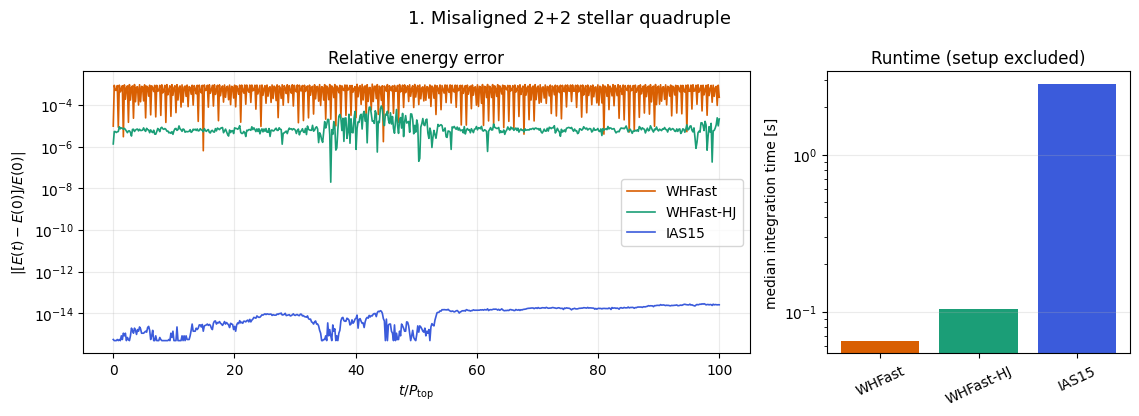

## Case 2: Circumbinary planet in a 2+2 quadruple

**Category:** planetary 3+2 branch. PH1/Kepler-64-inspired: a circumbinary planet belongs to one stellar pair while another tight binary forms the other branch. [Source: PH1 discovery](https://arxiv.org/abs/1210.3612).

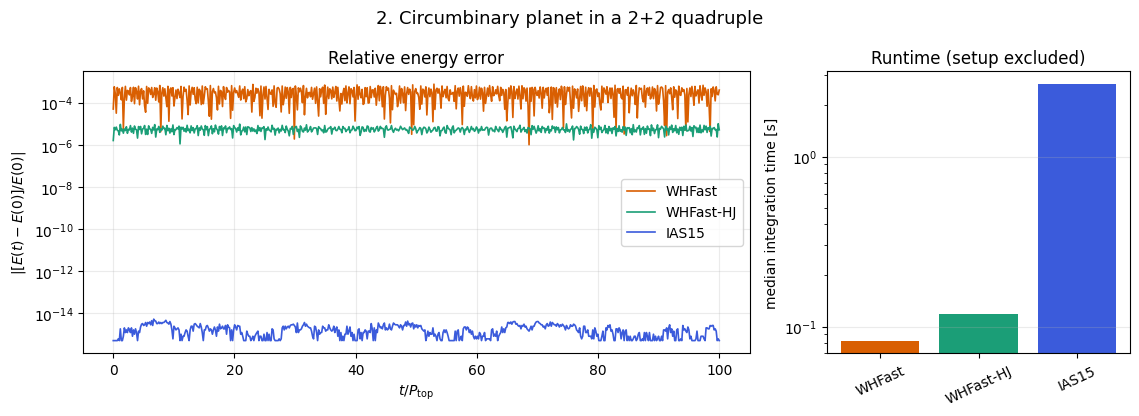

## Case 3: S-type planet in a 2+2 quadruple

**Category:** planet inside one stellar branch. 30 Ari-inspired and mass-amplified: a close S-type companion is nested around one member of a stellar binary, opposite a second stellar binary. [Source: 30 Ari in nested multiple dynamics](https://academic.oup.com/mnras/article/459/3/2827/2595187).

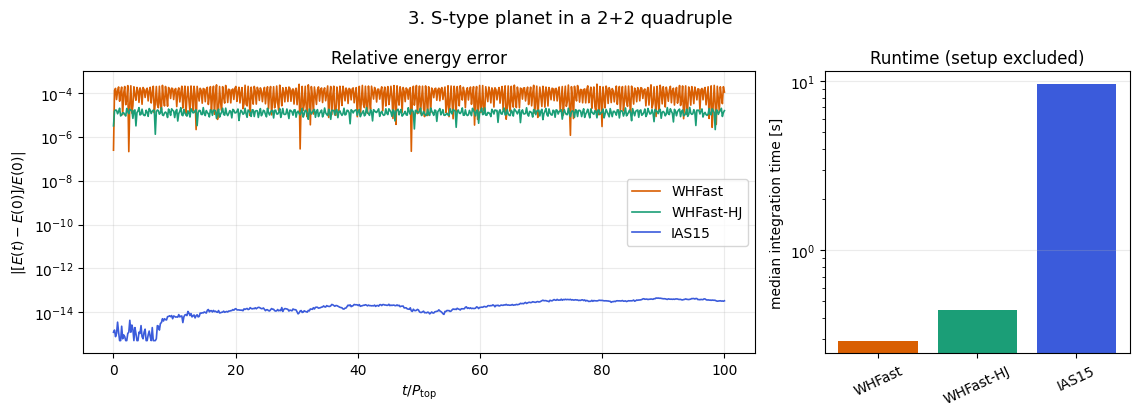

## Case 4: Three-binary sextuple

**Category:** three-level stellar sextuple. Castor-inspired and rescaled: two binaries form an inner 2+2 quadruple and a third binary orbits that quadruple. [Source: Castor sextuple architecture](https://www.aspbooks.org/a/volumes/article_details/?paper_id=37069).

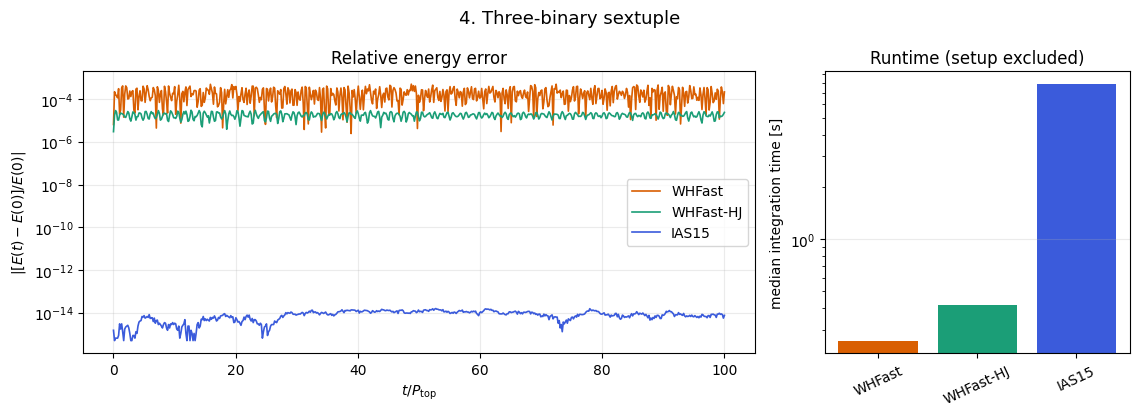

## Case 5: Two S-type multiplanet systems

**Category:** two planetary branches. A mass-amplified compact analogue of a wide stellar binary whose two components each host a two-planet system. [Source: Planets in binary-star systems](https://www.aanda.org/articles/aa/full_html/2026/03/aa57244-25/aa57244-25.html).

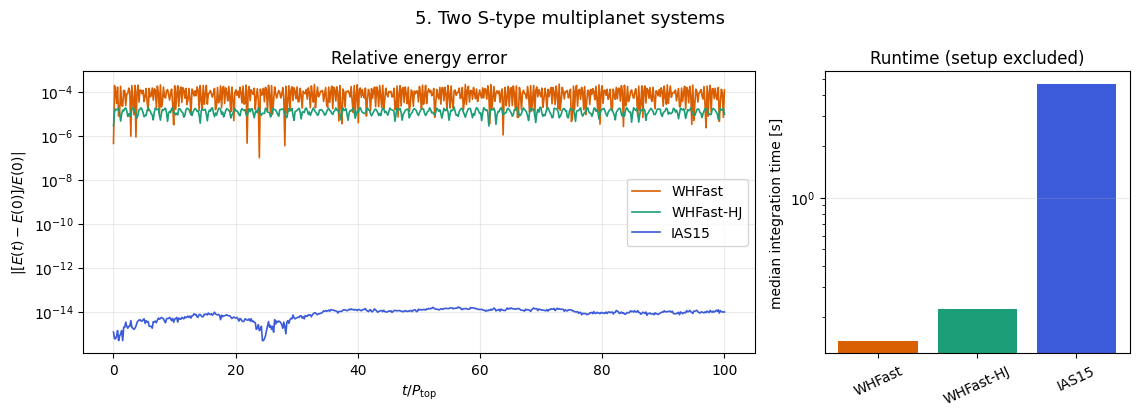

## Case 6: Two planet–moon systems in a stellar binary

**Category:** nested satellite branches. Each star hosts a giant planet–moon pair; both moon-scale Kepler problems live below the wide stellar orbit. [Source: Nested-binary hierarchy formalism](https://arxiv.org/abs/1511.00944).

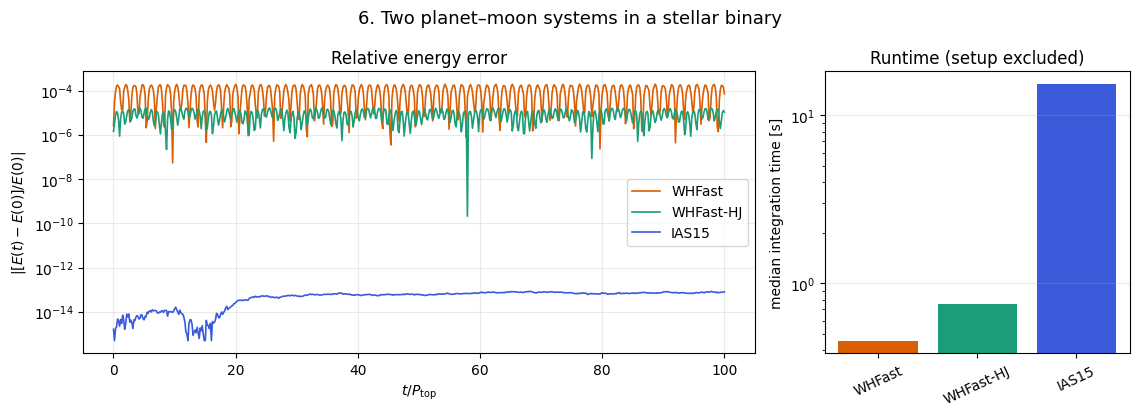

## Case 7: Planet-hosting hierarchical triple

**Category:** two occupied triple branches. A mass-amplified compact analogue: an inner binary carries a circumbinary planet while the tertiary carries an S-type planet. [Source: Planetary zones in hierarchical triples](https://academic.oup.com/mnras/article/382/4/1432/1142027).

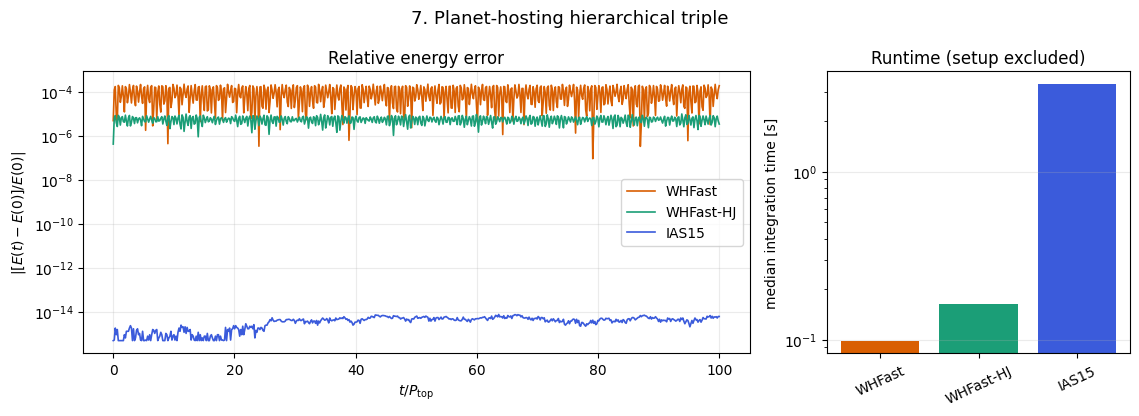

## Case 8: Twin circumbinary planetary systems

**Category:** two planetary triple branches. Two tight stellar binaries each carry a circumbinary planet; the planetary triples orbit one another. [Source: Arbitrary multiplanet and multistar hierarchies](https://arxiv.org/abs/1511.00944).

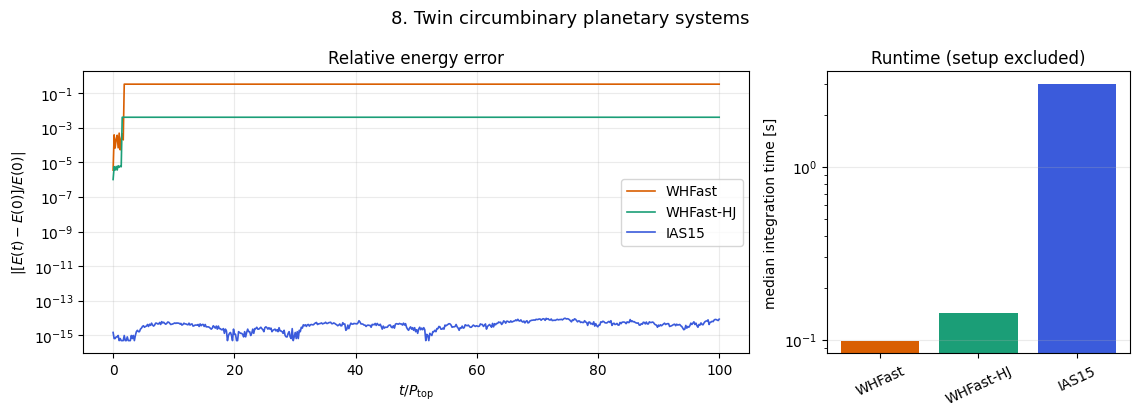

## Case 9: Circumbinary planet–moon plus outer binary

**Category:** binary planet branch in a quadruple. A planet–moon binary orbits one stellar binary while a second stellar binary forms the other outer branch. [Source: Nested-binary hierarchy formalism](https://arxiv.org/abs/1511.00944).

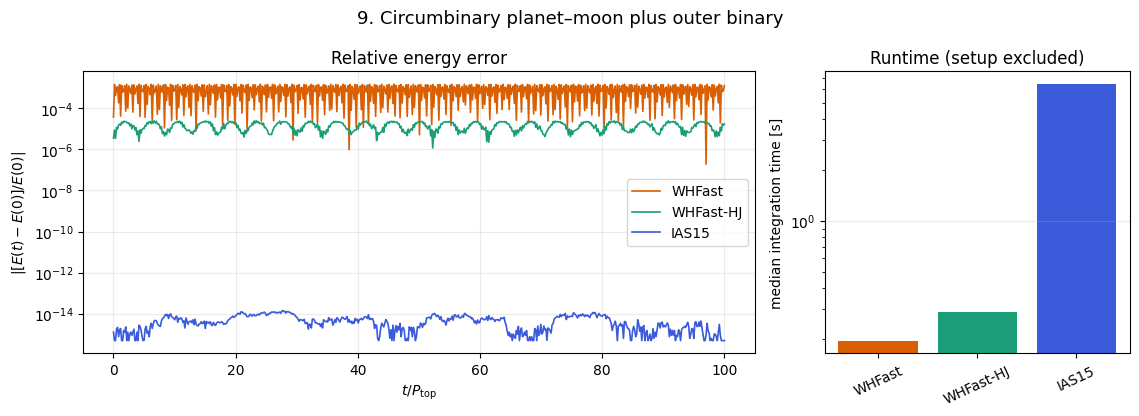

## Case 10: Balanced eight-body binary forest

**Category:** deep balanced hierarchy. Four tight binaries form two 2+2 quadruples, which then orbit one another; this tests tree depth and traversal cost. [Source: Architecture of hierarchical stellar systems](https://www.mdpi.com/2218-1997/7/9/352).

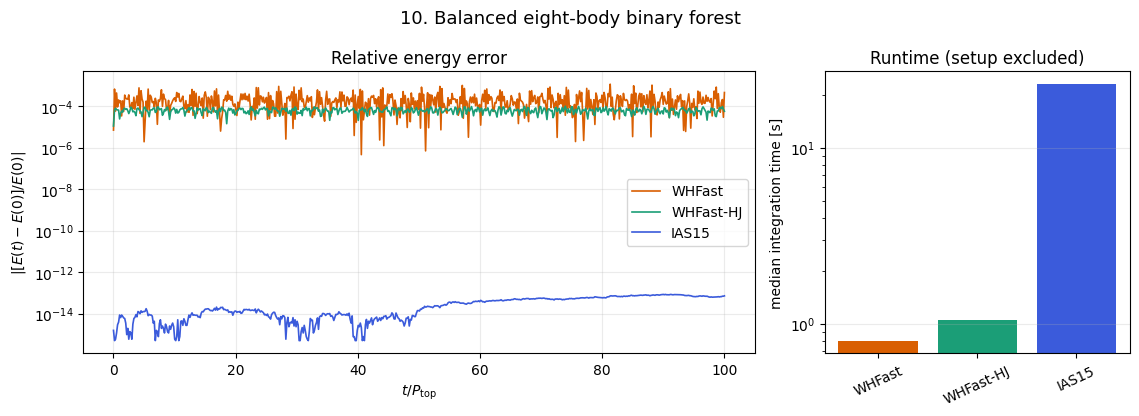

## Case 11: Ordered hierarchical triple

**Category:** comb control. The natural tree [[A,B],C] is already ordinary Jacobi form, so fixed-tree HJ should not improve accuracy. [Source: Hierarchical triple systems](https://academic.oup.com/mnras/article/382/4/1432/1142027).

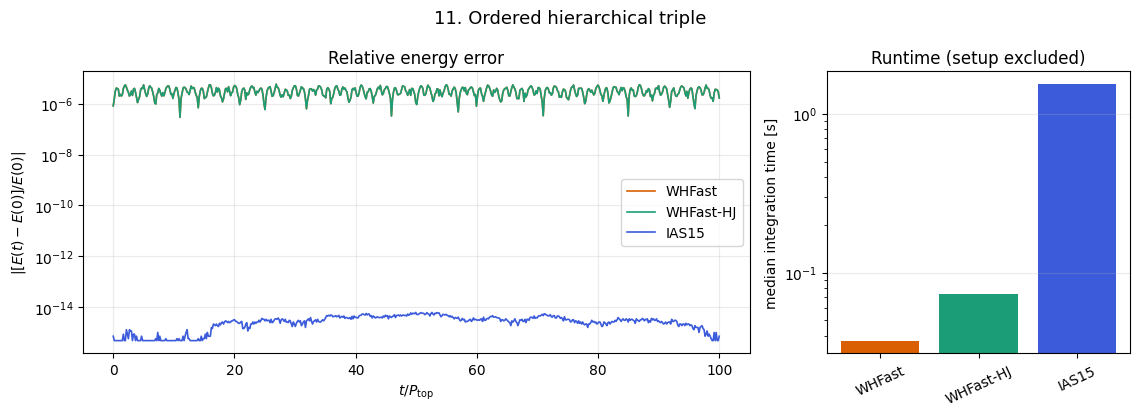

## Case 12: 3+1 stellar quadruple

**Category:** automatic-tree comb control. A pure comb [[[A,B],C],D] is representable by WHFast ordering; automatic HJ rebuilding adds overhead without changing the split. [Source: 3+1 hierarchical multiples](https://arxiv.org/abs/1511.00944).

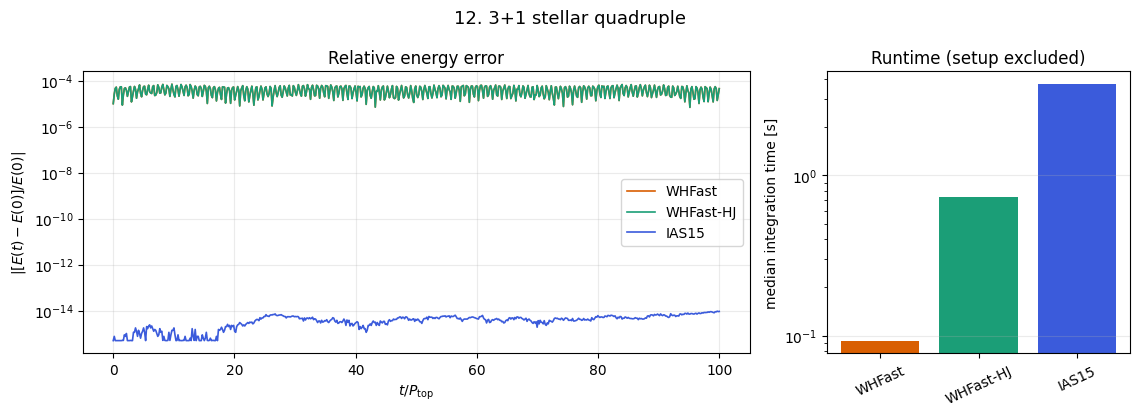

## Case 13: Scaled Sun–Pluto–Charon–moon chain

**Category:** satellite comb control. A mass-amplified Pluto analogue: Pluto–Charon plus two small circumbinary moons orbit a Sun. Reordering puts the whole hierarchy in one ordinary Jacobi comb. [Source: NASA Pluto moon system](https://science.nasa.gov/dwarf-planets/pluto/moons/facts/).

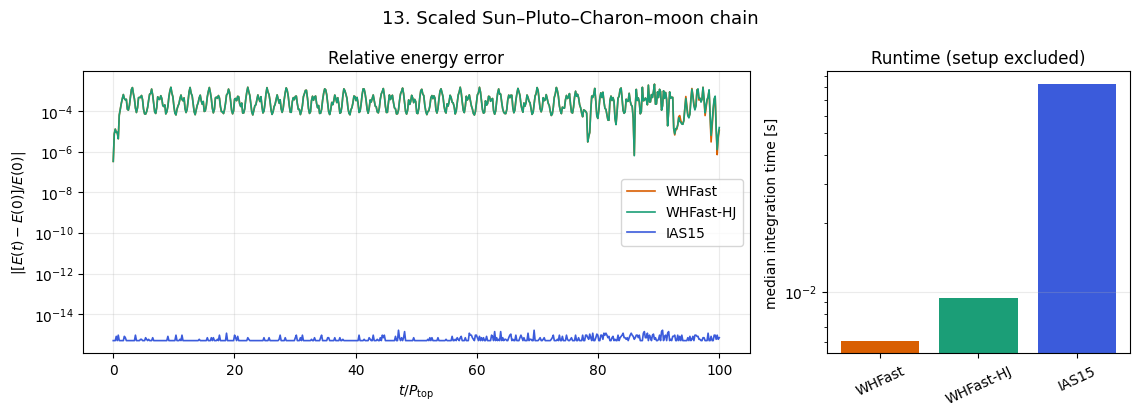

In [8]:
COLORS = {"whfast":"#d95f02", "whfast_hj":"#1b9e77", "ias15":"#3b5bdb"}
LABELS = {"whfast":"WHFast", "whfast_hj":"WHFast-HJ", "ias15":"IAS15"}

for number, case in enumerate(CASES, 1):
    result = RESULTS[case.key]
    display(Markdown(
        f"## Case {number}: {case.title}\n\n"
        f"**Category:** {case.category}. {case.description} "
        f"[Source: {case.source_label}]({case.source_url})."
    ))
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), gridspec_kw={"width_ratios":[2.2,1]})
    for integrator in ("whfast", "whfast_hj", "ias15"):
        run = result[integrator]
        axes[0].plot(run["time"], run["energy_error"], color=COLORS[integrator],
                     label=LABELS[integrator], lw=1.2)
    axes[0].set_yscale("log")
    axes[0].set_xlabel(r"$t/P_{\rm top}$")
    axes[0].set_ylabel(r"$|[E(t)-E(0)]/E(0)|$")
    axes[0].set_title("Relative energy error")
    axes[0].grid(alpha=.25)
    axes[0].legend()

    integrators = ("whfast", "whfast_hj", "ias15")
    runtimes = [result[name]["runtime"] for name in integrators]
    axes[1].bar([LABELS[name] for name in integrators], runtimes,
                color=[COLORS[name] for name in integrators])
    axes[1].set_yscale("log")
    axes[1].set_ylabel("median integration time [s]")
    axes[1].set_title("Runtime (setup excluded)")
    axes[1].tick_params(axis="x", rotation=25)
    axes[1].grid(axis="y", alpha=.25)
    fig.suptitle(f"{number}. {case.title}", fontsize=13)
    fig.tight_layout()
    plt.show()

## Summary and measured classification

Energy conservation is the primary metric, but it is not sufficient by itself: symplectic energy error can remain bounded while orbital phase diverges. The table therefore reports separate dimensionless RMS position (`dx`) and velocity (`dv`) differences relative to IAS15; positions and velocities are never combined into one dimensionality-invalid norm. A case is labeled a measured HJ win only when the long-run **maximum** energy-error ratio is at least ten and HJ costs no more than three times WHFast. The RMS energy-error ratio is shown alongside it to expose sensitivity to isolated peaks. Any disagreement with the expected label is retained rather than hidden.

case                     expected  measured     max W/HJ   rms W/HJ  time HJ/W      dx W     dx HJ      dv W     dv HJ
----------------------------------------------------------------------------------------------------------------------
01_hd98800               win       HJ win          11.11      49.15       1.58  1.18e-01  1.77e-02  1.42e+00  3.20e-01
02_ph1                   win       HJ win          76.25      64.28       1.43  4.62e-01  8.67e-02  1.74e+00  3.05e-01
03_30ari                 win       HJ win          11.60       9.12       1.51  4.12e-02  3.32e-02  8.41e-01  1.63e+00
04_castor                win       HJ win          16.62      12.15       1.60  1.36e+00  6.08e-02  1.01e+00  1.46e+00
05_double_multiplanet    win       HJ win          11.06       8.00       1.54  8.84e-02  5.76e-02  1.32e+00  1.12e+00
06_double_moons          win       HJ win          11.85      11.89       1.65  2.28e-02  1.31e-02  8.27e-01  9.64e-01
07_triple_planets        win       HJ win       

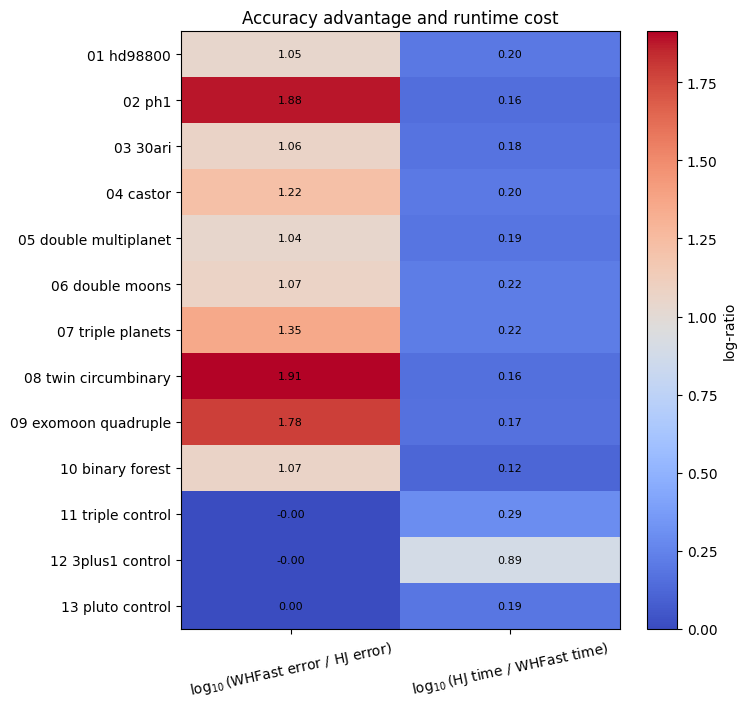

confirmed wins among first ten: 10/10
controls where HJ is not worthwhile: 3/3
total benchmark runtime: 6.11 min


In [9]:
SUMMARY = []
header = (f"{'case':24s} {'expected':9s} {'measured':10s} {'max W/HJ':>10s} "
          f"{'rms W/HJ':>10s} {'time HJ/W':>10s} {'dx W':>9s} {'dx HJ':>9s} "
          f"{'dv W':>9s} {'dv HJ':>9s}")
print(header)
print("-"*len(header))
for case in CASES:
    result = RESULTS[case.key]
    error_ratio = result["whfast"]["max_error"]/result["whfast_hj"]["max_error"]
    rms_ratio = result["whfast"]["rms_error"]/result["whfast_hj"]["rms_error"]
    runtime_ratio = result["whfast_hj"]["runtime"]/result["whfast"]["runtime"]
    measured = "HJ win" if error_ratio >= 10 and runtime_ratio <= 3 else "not worth"
    row = {"case":case.key, "title":case.title, "expected":case.expected,
           "measured":measured, "error_ratio":error_ratio, "rms_ratio":rms_ratio,
           "runtime_ratio":runtime_ratio,
           "whfast_error":result["whfast"]["max_error"],
           "hj_error":result["whfast_hj"]["max_error"],
           "ias15_error":result["ias15"]["max_error"],
           "whfast_rms":result["whfast"]["rms_error"],
           "hj_rms":result["whfast_hj"]["rms_error"],
           "ias15_rms":result["ias15"]["rms_error"],
           "whfast_runtime":result["whfast"]["runtime"],
           "hj_runtime":result["whfast_hj"]["runtime"],
           "ias15_runtime":result["ias15"]["runtime"],
           "whfast_position_error":result["whfast"]["position_error"],
           "hj_position_error":result["whfast_hj"]["position_error"],
           "whfast_velocity_error":result["whfast"]["velocity_error"],
           "hj_velocity_error":result["whfast_hj"]["velocity_error"]}
    SUMMARY.append(row)
    print(f"{case.key:24s} {case.expected:9s} {measured:10s} {error_ratio:10.2f} "
          f"{rms_ratio:10.2f} {runtime_ratio:10.2f} "
          f"{row['whfast_position_error']:9.2e} {row['hj_position_error']:9.2e} "
          f"{row['whfast_velocity_error']:9.2e} {row['hj_velocity_error']:9.2e}")

print("\nDetailed error and runtime table")
detail_header = (f"{'case':24s} {'W max':>10s} {'W rms':>10s} {'W sec':>8s} "
                 f"{'HJ max':>10s} {'HJ rms':>10s} {'HJ sec':>8s} "
                 f"{'I max':>10s} {'I rms':>10s} {'I sec':>8s}")
print(detail_header)
print("-"*len(detail_header))
for row in SUMMARY:
    print(f"{row['case']:24s} {row['whfast_error']:10.2e} {row['whfast_rms']:10.2e} "
          f"{row['whfast_runtime']:8.3f} {row['hj_error']:10.2e} {row['hj_rms']:10.2e} "
          f"{row['hj_runtime']:8.3f} {row['ias15_error']:10.2e} {row['ias15_rms']:10.2e} "
          f"{row['ias15_runtime']:8.3f}")

labels = [row["case"].replace("_", " ") for row in SUMMARY]
matrix = np.array([[np.log10(max(row["error_ratio"], 1e-12)),
                    np.log10(max(row["runtime_ratio"], 1e-12))] for row in SUMMARY])
fig, ax = plt.subplots(figsize=(7.5, 7.2))
image = ax.imshow(matrix, aspect="auto", cmap="coolwarm")
ax.set_xticks([0,1], [r"$\log_{10}$(WHFast error / HJ error)",
                       r"$\log_{10}$(HJ time / WHFast time)"], rotation=12)
ax.set_yticks(np.arange(len(labels)), labels)
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        ax.text(j, i, f"{matrix[i,j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=ax, label="log-ratio")
ax.set_title("Accuracy advantage and runtime cost")
fig.tight_layout()
plt.show()

measured_wins = sum(row["measured"] == "HJ win" for row in SUMMARY[:10])
measured_controls = sum(row["measured"] == "not worth" for row in SUMMARY[10:])
print(f"confirmed wins among first ten: {measured_wins}/10")
print(f"controls where HJ is not worthwhile: {measured_controls}/3")
print(f"total benchmark runtime: {TOTAL_BENCHMARK_SECONDS/60:.2f} min")

## Interpretation and limitations

### Observations from this run

- All ten branching cases satisfy the predefined long-run **maximum** energy-error criterion, with fixed-tree HJ costing about 1.3–1.6 times ordinary WHFast. This supports an accuracy–cost advantage for these examples, not a universal guarantee.
- The conclusion is weaker under an RMS criterion: cases 3, 5, and 10 improve by less than a factor of ten in RMS energy error. Case 10 also misses the tenfold threshold in every short timestep screen. The 10/10 count is therefore specific to the declared maximum-error statistic and long horizon.
- Cases 11 and 12 give matching WHFast and HJ energy errors, as expected for exact Jacobi combs. Case 13 must use the imposed order `(Pluto, Charon, Nix, Hydra, Sun)`; choosing its order from a short pilot previously produced a transiently favorable but hierarchy-incompatible control.
- Case 8 is not a valid fixed-hierarchy accuracy benchmark over 100 outer periods. Its timestep study is non-monotonic, and an independent IAS15 diagnostic finds a cross-hierarchy close approach between `A2` and `B planet` with sampled separation about 0.423 at $t\simeq1.64P_{\rm top}$. The original hierarchy has broken down, so the apparent HJ advantage at some timesteps must not be interpreted as a converged trajectory. Case 8 should be redesigned as a stable hierarchy or explicitly relabeled as an encounter stress test.

### Scope and caveats

- A large HJ advantage is often expected when the physical system contains **two or more simultaneously important branches**. The tree places each tight binary, planet–moon pair, or planetary subsystem inside its own Kepler Hamiltonian.
- A simple triple, a 3+1 chain, or the correctly reordered Pluto control is already a Jacobi comb. In these cases WHFast-HJ performs essentially the same split with additional tree traversal—and, for the automatic case, tree-rebuilding—overhead.
- IAS15 is adaptive and not symplectic. Its nearly machine-level energy errors provide a useful finite-time reference, while WHFast methods are intended for inexpensive long integrations with bounded error.
- These tests were intended to exclude close encounters and hierarchy changes, but the case-8 follow-up shows that the current case 8 violates that assumption. The other cases have not yet received the same explicit minimum-separation audit. The fixed-step Stumpff overflow diagnosed in `0727_debug.ipynb` can affect both WHFast variants when an encounter is unresolved.
- Total relative energy can be dominated by the tightest binary. Separate IAS15-referenced position and velocity errors help expose phase error, but a single final Cartesian state can itself be phase-sensitive and should be supplemented with orbital-element diagnostics.
- The branching-case order search uses a short pilot and can favor transient cancellation. The selected orders should be checked over multiple horizons or initial phases before being treated as generally optimal.
- These are inspired, rescaled benchmarks with one initial phase per architecture. They do not establish performance across the physical parameter distribution of the named observed systems.
- Runtime conclusions apply to this REBOUND implementation, compiler, and machine. Fixed-tree parsing and all Python plotting/sampling work are excluded; automatic hierarchy discovery is included where explicitly selected.

## Follow-up experiment: timestep convergence for case 8

Case 8 has the largest relative HJ energy advantage, but its full-run absolute energy and final-state errors are too large to claim a converged trajectory at $\Delta t=P_{\min}/20$. The following experiment repeats WHFast and WHFast-HJ with $d\in\{20,40,80,160\}$ in $\Delta t=P_{\min}/d$.

All runs end at the same exactly step-compatible time, so final-state differences are not contaminated by comparing slightly different epochs. A single IAS15 integration supplies the final-state reference. Quick mode uses only $d=20,40$ and a shorter horizon.

In [10]:
CASE08 = next(case for case in CASES if case.key == "08_twin_circumbinary")
CASE08_DIVISORS = (20, 40) if QUICK else (20, 40, 80, 160)
CASE08_TOP_PERIODS = 0.05 if QUICK else 100.0
CASE08_OUTPUTS = 24 if QUICK else 600
case08_order = OPTIMAL_ORDERS[CASE08.key]
case08_data = case_data(CASE08)

# Choose a target that is an integer number of steps for every tested divisor.
case08_coarse_dt = case08_data["p_min"]/min(CASE08_DIVISORS)
case08_coarse_steps = int(np.ceil(
    CASE08_TOP_PERIODS*case08_data["p_top"]/case08_coarse_dt))
CASE08_TARGET = case08_coarse_steps*case08_coarse_dt

# One high-accuracy final-state reference at exactly the common target time.
case08_reference_sim, _, _ = make_simulation(
    CASE08, case08_order, "ias15")
case08_reference_sim.integrate(CASE08_TARGET, exact_finish_time=1)
case08_reference = named_state(case08_reference_sim, case08_order)


def case08_convergence_run(integrator, divisor):
    sim, data, tree = make_simulation(
        CASE08, case08_order, integrator, divisor=divisor)
    steps = int(round(CASE08_TARGET/sim.dt))
    assert np.isclose(steps*sim.dt, CASE08_TARGET, rtol=0, atol=1e-12)
    marks = np.unique(np.linspace(1, steps, CASE08_OUTPUTS, dtype=int))
    energy0 = sim.energy()
    if integrator == "whfast_hj":
        sim.integrate(sim.t, given_tree=True, tree=tree)
    previous = 0
    energy_errors = []
    start = time.perf_counter()
    with warnings.catch_warnings():
        warnings.simplefilter("error")
        for mark in marks:
            sim.steps(int(mark-previous))
            previous = int(mark)
            energy_errors.append(relative_energy_error(sim, energy0))
    sampled_seconds = time.perf_counter()-start
    values = np.asarray(energy_errors)
    if not np.all(np.isfinite(values)):
        raise FloatingPointError(
            f"non-finite case-08 trajectory for {integrator} P_min/{divisor}")
    sim.synchronize()
    state_errors = normalized_state_errors(
        named_state(sim, case08_order), case08_reference)
    return {
        "integrator": integrator, "divisor": divisor,
        "dt_over_pmin": 1/divisor, "steps": steps,
        "max_energy": float(values.max()),
        "rms_energy": float(np.sqrt(np.mean(values**2))),
        "position_error": state_errors["position"],
        "velocity_error": state_errors["velocity"],
        "sampled_seconds": sampled_seconds,
    }


CASE08_CONVERGENCE = []
for divisor in CASE08_DIVISORS:
    for integrator in ("whfast", "whfast_hj"):
        run = case08_convergence_run(integrator, divisor)
        CASE08_CONVERGENCE.append(run)
        print(f"{integrator:9s} dt=P_min/{divisor:<3d} "
              f"maxE={run['max_energy']:.3e} rmsE={run['rms_energy']:.3e} "
              f"dx={run['position_error']:.3e} dv={run['velocity_error']:.3e} "
              f"sampled={run['sampled_seconds']:.3f}s")

whfast    dt=P_min/20  maxE=3.382e-01 rmsE=3.347e-01 dx=5.243e+01 dv=1.315e+01 sampled=0.103s
whfast_hj dt=P_min/20  maxE=4.128e-03 rmsE=4.093e-03 dx=3.809e+00 dv=1.808e+00 sampled=0.147s
whfast    dt=P_min/40  maxE=1.388e-04 rmsE=6.985e-05 dx=1.826e+00 dv=1.207e+00 sampled=0.206s
whfast_hj dt=P_min/40  maxE=1.852e-05 rmsE=8.269e-06 dx=2.457e+00 dv=1.376e+00 sampled=0.304s
whfast    dt=P_min/80  maxE=5.718e-05 rmsE=1.785e-05 dx=3.967e+00 dv=1.807e+00 sampled=0.404s
whfast_hj dt=P_min/80  maxE=5.334e-07 rmsE=3.197e-07 dx=7.931e-01 dv=1.244e+00 sampled=0.598s
whfast    dt=P_min/160 maxE=1.062e-04 rmsE=6.956e-05 dx=2.729e+00 dv=1.517e+00 sampled=0.764s
whfast_hj dt=P_min/160 maxE=2.025e-02 rmsE=2.008e-02 dx=1.069e+01 dv=2.799e+00 sampled=1.189s


method       d    dt/Pmin        maxE        rmsE          dx          dv      steps
------------------------------------------------------------------------------------
whfast      20    0.05000   3.382e-01   3.347e-01   5.243e+01   1.315e+01     118546
whfast_hj   20    0.05000   4.128e-03   4.093e-03   3.809e+00   1.808e+00     118546
whfast      40    0.02500   1.388e-04   6.985e-05   1.826e+00   1.207e+00     237092
whfast_hj   40    0.02500   1.852e-05   8.269e-06   2.457e+00   1.376e+00     237092
whfast      80    0.01250   5.718e-05   1.785e-05   3.967e+00   1.807e+00     474184
whfast_hj   80    0.01250   5.334e-07   3.197e-07   7.931e-01   1.244e+00     474184
whfast     160    0.00625   1.062e-04   6.956e-05   2.729e+00   1.517e+00     948368
whfast_hj  160    0.00625   2.025e-02   2.008e-02   1.069e+01   2.799e+00     948368


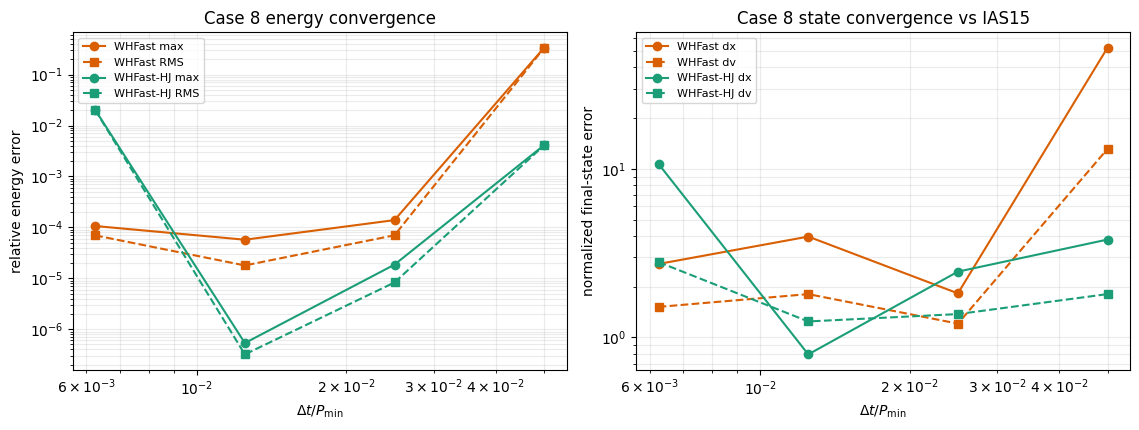

In [11]:
header = (f"{'method':9s} {'d':>4s} {'dt/Pmin':>10s} {'maxE':>11s} "
          f"{'rmsE':>11s} {'dx':>11s} {'dv':>11s} {'steps':>10s}")
print(header)
print("-"*len(header))
for run in CASE08_CONVERGENCE:
    print(f"{run['integrator']:9s} {run['divisor']:4d} "
          f"{run['dt_over_pmin']:10.5f} {run['max_energy']:11.3e} "
          f"{run['rms_energy']:11.3e} {run['position_error']:11.3e} "
          f"{run['velocity_error']:11.3e} {run['steps']:10d}")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
for integrator in ("whfast", "whfast_hj"):
    rows = [row for row in CASE08_CONVERGENCE
            if row["integrator"] == integrator]
    rows.sort(key=lambda row: row["dt_over_pmin"])
    x = np.asarray([row["dt_over_pmin"] for row in rows])
    color = COLORS[integrator]
    label = LABELS[integrator]
    axes[0].loglog(x, [row["max_energy"] for row in rows], "o-",
                   color=color, label=f"{label} max")
    axes[0].loglog(x, [row["rms_energy"] for row in rows], "s--",
                   color=color, label=f"{label} RMS")
    axes[1].loglog(x, [row["position_error"] for row in rows], "o-",
                   color=color, label=f"{label} dx")
    axes[1].loglog(x, [row["velocity_error"] for row in rows], "s--",
                   color=color, label=f"{label} dv")
for ax in axes:
    ax.set_xlabel(r"$\Delta t/P_{\min}$")
    ax.grid(alpha=.25, which="both")
    ax.legend(fontsize=8)
axes[0].set_ylabel("relative energy error")
axes[0].set_title("Case 8 energy convergence")
axes[1].set_ylabel("normalized final-state error")
axes[1].set_title("Case 8 state convergence vs IAS15")
fig.tight_layout()
plt.show()

### How to interpret the case-08 convergence study

A converged result should show decreasing maximum and RMS energy errors **and** decreasing `dx` and `dv` as $\Delta t$ is reduced. For a clean second-order regime, halving $\Delta t$ should reduce the leading error by roughly a factor of four, although long-time phase error need not follow an exact power law. A flat curve indicates an error floor; an irregular or increasing state-error curve can indicate phase sensitivity, chaotic divergence, or a timestep that is still outside the asymptotic regime.

### Conclusion from the current full run

Case 8 does **not** converge monotonically over 100 outer periods. HJ improves from $P_{\min}/20$ through $P_{\min}/80$, but at $P_{\min}/160$ its maximum energy error rises to about $2.0\times10^{-2}$ and its normalized position error rises to about 10.7. WHFast is also non-monotonic. Even the best HJ energy result at $P_{\min}/80$ retains substantial final-state disagreement (`dx` about 0.79 and `dv` about 1.24).

An independent IAS15 run sampled at 5,000 times finds `A2` and `B planet` separated by only about 0.423 near $1.64P_{\rm top}$. This cross-branch approach is smaller than the tight-binary semimajor-axis scale, so the assumed binary tree is no longer physically valid. After this encounter, timestep-dependent trajectories separate chaotically and a fixed-tree HJ split is no longer appropriate. These results should be presented as evidence of hierarchy breakdown, not as a converged HJ accuracy win.